# Проект. Карты ДТП

Автор: Казанцев Павел

## Введение

«Карты ДТП» — некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России. **Цель проекта** — повысить безопасность на дорогах.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах. Заказчик хочет собирать данные более высокого качества и ожидает от вас рекомендаций: на какие проблемы или особенности обратить внимание.

Необходимо выполнить предобработку данных, проверить данные на пропуски, дубликаты, корректность типов данных и ответить на вопросы заказчика.

### Вопросы заказчика

1. как менялось число ДТП по временным промежуткам;

2. различается ли число ДТП для групп водителей с разным стажем.

3. Как распределено количество участников ДТП и почему? Встречаются ли аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для числа участников найдите наиболее типичное значение. По желанию можете проверить распределения и других столбцов.

4. Предположите, между какими столбцами в датасете `Kirovskaya_oblast.csv` высокая корреляция. Проверьте своё предположение.  

5. Как связаны категории аварий и погодные условия?

6. Постройте процентную разбивку аварий по видам освещённости. При этом учитывайте пол участника и сделайте расчёты для мужчин и женщин отдельно.

7. Исследуйте, чем отличаются аварии без пострадавших от тех, в которых был один пострадавший или более.

8. Сделайте общий вывод о связи аварийности с другими факторами. Какие рекомендации вы можете дать заказчику?

# Описание данных

Датасеты `https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv`, `https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv` содержат информацию о ДТП:

- `geometry.coordinates` — координаты ДТП;
- `id` — идентификатор ДТП;
- `properties.tags` — тег происшествия;
- `properties.light` — освещённость;
- `properties.point.lat` — широта;
- `properties.point.long` — долгота;
- `properties.nearby` — ближайшие объекты;
- `properties.region` — регион;
- `properties.scheme` — схема ДТП;
- `properties.address` — ближайший адрес;
- `properties.weather` — погода;
- `properties.category` — категория ДТП;
- `properties.datetime` — дата и время ДТП;
- `properties.injured_count` — число пострадавших;
- `properties.parent_region` — область;
- `properties.road_conditions` — состояние покрытия;
- `properties.participants_count` — число участников;
- `properties.participant_categorie` — категории участников.

Датасеты `https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv`, `https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv` хранят сведения об участниках ДТП:

- `role` — роль;
- `gender` — пол;
- `violations` — какие правила дорожного движения были нарушены конкретным участником;
- `health_status` — состояние здоровья после ДТП;
- `years_of_driving_experience` — число лет опыта;
- `id` — идентификатор ДТП.

Датасеты `https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv`, `https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv` хранят сведения о транспортных средствах:

- `year` — год выпуска;
- `brand` — марка транспортного средства;
- `color` — цвет;
- `model` — модель;
- `category` — категория;
- `id` — идентификатор ДТП.

## 1. Загружаем данные и библиотеки для работы

In [1]:
# Для начала необходимо установить библиотеки
%pip install jupyter_black

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Загрузим необходимые библиотеки для работы
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from phik import phik_matrix
import seaborn as sns
import numpy as np

import jupyter_black

jupyter_black.load()

In [3]:
# Выгружаем данные в переменные

# содержат информацию о ДТП:
kirov_obl = pd.read_csv("https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv")

# хранят сведения об участниках ДТП:
kirov_obl_people = pd.read_csv(
    "https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv"
)

# хранят сведения о транспортных средствах:
kirov_obl_vehicles = pd.read_csv(
    "https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv"
)

### 1.1 Знакомство с данными

In [4]:
# Выведем случайные строки датасетов для просмотра и определим размерность датасета через атрибут .shape

display(kirov_obl.sample(2), kirov_obl.shape)

display(kirov_obl_people.sample(2), kirov_obl_people.shape)

display(kirov_obl_vehicles.sample(2), kirov_obl_vehicles.shape)

,geometry.coordinates,id,properties.tags,properties.light,properties.point.lat,properties.point.long,properties.nearby,properties.region,properties.scheme,properties.address,properties.weather,properties.category,properties.datetime,properties.injured_count,properties.parent_region,properties.road_conditions,properties.participants_count,properties.participant_categories
2470,"[48.958104, 59.386698]",1981317,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",59.386698,48.958104,['Нерегулируемый перекрёсток равнозначных улиц...,Мурашинский район,910.0,"г Мураши, ул Труда, 9",['Пасмурно'],Наезд на стоящее ТС,2016-02-26 23:10:00,1,Кировская область,['Со снежным накатом'],2,['Все участники']
10562,"[49.591233, 58.636684]",1980445,Дорожно-транспортные происшествия,"В темное время суток, освещение включено",58.636684,49.591233,"['Производственное предприятие', 'Жилые дома и...",Киров,300.0,"г Киров, ул Дзержинского, 77",['Пасмурно'],Столкновение,2016-12-15 21:25:00,2,Кировская область,['Обработанное противогололедными материалами'],4,['Все участники']


(14517, 18)

,role,gender,violations,health_status,years_of_driving_experience,id
14232,Водитель,Мужской,['Нарушение правил проезда пешеходного перехода'],Не пострадал,18.0,1988507
30924,Пешеход,Мужской,['Неподчинение сигналам регулирования'],"Раненый, находящийся (находившийся) на стацион...",NaN,1983400


(31235, 6)

,year,brand,color,model,category,id
4222,2013.0,УАЗ,Белый,3909,Фургоны,2498717
15088,2017.0,VOLKSWAGEN,Черный,Polo,"С-класс (малый средний, компактный) до 4,3 м",2875649


(20093, 6)

Названия столбцов в датасетах с информацией о ДТП написаны через точку, рекомендуется стиль snake_case.

## 2. Проверка ошибок в данных и их предобработка

### 2.1 Замена названий (меток) столбцов на оптимальные для работы

In [5]:
# Исправим стиль написания столбцов в датасетах на snake_case
kirov_obl.columns = kirov_obl.columns.str.replace(".", "_")

# Для удобства обращения в столбцам уберем приписку properties_
kirov_obl.columns = kirov_obl.columns.str.replace("properties_", "")

display(kirov_obl.columns)

Index(['geometry_coordinates', 'id', 'tags', 'light', 'point_lat',
       'point_long', 'nearby', 'region', 'scheme', 'address', 'weather',
       'category', 'datetime', 'injured_count', 'parent_region',
       'road_conditions', 'participants_count', 'participant_categories'],
      dtype='object')

### 2.2 Проверка пропусков в данных

In [6]:
# На примере датасета Кировской области проверим в каких столбцах встречаются пропуски
kirov_obl.isna().sum().sort_values(ascending=False)

scheme                    1137
address                    674
point_long                  32
point_lat                   32
id                           0
geometry_coordinates         0
tags                         0
light                        0
region                       0
nearby                       0
weather                      0
category                     0
datetime                     0
injured_count                0
parent_region                0
road_conditions              0
participants_count           0
participant_categories       0
dtype: int64

Чаще всего пропуски встречаются `scheme`, столбец показывает числовые данные указанные на схеме ДТП. Заполнить такие данные сложно, ведь мы не знаем из какого источника берутся данные о схемах ДТП. 

Стоит уточнить у заказчика, при каких ДТП схема может не заполняться и насколько этот столбец важен. Такие уточнения помогут сформулировать рекомендации по сбору данных.

Часто не указан ближайший адрес ДТП. Возможно ДТП произошло за городом в открытой местности (полях), где нет адреса. Можем свериться со столбцом `nearby`, который показывает какие ближайшие объекты были в момент ДТП

In [7]:
kirov_obl.loc[kirov_obl["address"].isna()]

,geometry_coordinates,id,tags,light,point_lat,point_long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
18,"[47.703667, 57.398549]",1981028,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",57.398549,47.703667,[],Яранский район,820.0,NaN,['Пасмурно'],Наезд на пешехода,2018-05-01 22:10:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Пешеходы']"
59,"[47.969474, 57.105731]",2875566,Дорожно-транспортные происшествия,Светлое время суток,57.105731,47.969474,[],Яранский район,950.0,NaN,['Ясно'],Опрокидывание,2023-08-13 16:20:00,1,Кировская область,['Сухое'],1,['Все участники']
63,"[47.891099, 57.309193]",2875597,Дорожно-транспортные происшествия,Светлое время суток,57.309193,47.891099,"['Многоквартирные жилые дома', 'Внутридворовая...",Яранский район,410.0,NaN,['Ясно'],Столкновение,2023-08-01 12:35:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
95,"[47.906871, 57.020891]",2861063,Дорожно-транспортные происшествия,Светлое время суток,57.020891,47.906871,[],Яранский район,600.0,NaN,['Пасмурно'],Съезд с дороги,2023-07-22 03:50:00,3,Кировская область,['Мокрое'],3,['Все участники']
130,"[47.828239, 57.298419]",1984517,Дорожно-транспортные происшествия,Светлое время суток,57.298419,47.828239,"['АЗС', 'Автостоянка (отделенная от проезжей ч...",Яранский район,830.0,NaN,['Ясно'],Наезд на пешехода,2020-06-25 08:50:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Пешеходы']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14489,"[51.079023, 56.227214]",1983961,Дорожно-транспортные происшествия,Светлое время суток,56.227214,51.079023,"['Многоквартирные жилые дома', 'Внутридворовая...",Вятско-Полянский район,880.0,NaN,['Ясно'],Наезд на пешехода,2020-04-18 10:30:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Пешеходы']"
14497,"[51.293557, 56.251791]",1986098,Дорожно-транспортные происшествия,"В темное время суток, освещение не включено",56.251791,51.293557,"['Многоквартирные жилые дома', 'Внутридворовая...",Вятско-Полянский район,NaN,NaN,['Пасмурно'],Наезд на велосипедиста,2020-08-19 18:11:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Велосипедисты', 'Дети']"
14502,"[51.072639, 56.221047]",1986546,Дорожно-транспортные происшествия,Светлое время суток,56.221047,51.072639,"['Многоквартирные жилые дома', 'Внутридворовая...",Вятско-Полянский район,880.0,NaN,['Ясно'],Наезд на пешехода,2019-09-03 11:20:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Пешеходы']"
14511,"[51.1186, 56.2417]",1980230,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",56.241700,51.118600,[],Вятско-Полянский район,NaN,NaN,['Ясно'],Наезд на препятствие,2018-07-02 19:25:00,1,Кировская область,"['Сухое', 'Дефекты покрытия']",1,"['Все участники', 'Мотоциклисты']"


In [8]:
kirov_obl.loc[kirov_obl["address"].isna()]["nearby"].value_counts().sort_values(
    ascending=False
)

nearby
[]                                                                                                                                                                      183
['Многоквартирные жилые дома', 'Внутридворовая территория']                                                                                                             161
['Жилые дома индивидуальной застройки']                                                                                                                                  41
['Многоквартирные жилые дома', 'Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта)', 'Внутридворовая территория']            20
['Многоквартирные жилые дома']                                                                                                                                           14
                                                                                                                                     

Не все строки с ближайшими объектами пустые, значит нельзя полностью утверждать, что отсутствие ориентиров в виде ближайших объектов является пропусками адреса.

В принципе, складывается ощущение, что адреса не являются обязательными к заполнению. 

**Главным ориентиром ДТП являются сами координаты ДТП** (столбцы `geometry_coordinates`, `point_lat`, `point_long`), по ним можно определить и адрес, и объекты, посмотреть какая погода была в момент аварии. 

В данном датасете пропусков в координатах ДТП мало, но сам факт, что пропуски есть - это проблема, так как это самая важная часть в определении локации. Должной рекомендацией для заказчика будет обязательным заполнением координат ДТП

### 2.3 Наличие явных и неявных дубликатов

In [9]:
# Проверим наличие полных дубликатов
kirov_obl.duplicated().sum()

np.int64(0)

In [10]:
# Проверим данные на неявные дубликаты по координатам и времени ДТП
kirov_obl[kirov_obl.duplicated(subset=["point_lat", "point_long", "datetime"])]

,geometry_coordinates,id,tags,light,point_lat,point_long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories


In [11]:
# Проверим уникальность идентификатором
kirov_obl["id"].nunique() == kirov_obl["id"].count()

np.True_

Явных и неявных дубликатов в данных не выявлено

### 2.4 Проверка корректности типов данных

In [12]:
kirov_obl.dtypes

geometry_coordinates       object
id                          int64
tags                       object
light                      object
point_lat                 float64
point_long                float64
nearby                     object
region                     object
scheme                    float64
address                    object
weather                    object
category                   object
datetime                   object
injured_count               int64
parent_region              object
road_conditions            object
participants_count          int64
participant_categories     object
dtype: object

In [13]:
kirov_obl.head()

,geometry_coordinates,id,tags,light,point_lat,point_long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


Столбец `datetime` обязательно нужно преобразовать в тип `datetime`, так как он понадобится для расчетов в разрезе даты и времени

In [14]:
kirov_obl["datetime"] = kirov_obl["datetime"].astype("datetime64[ns]")
kirov_obl["datetime"]

0       2017-07-01 18:00:00
1       2023-09-12 17:10:00
2       2021-07-02 21:25:00
3       2021-05-31 18:55:00
4       2018-05-16 16:25:00
                ...        
14512   2018-05-17 06:20:00
14513   2019-05-30 18:35:00
14514   2019-05-13 09:20:00
14515   2015-08-12 17:05:00
14516   2016-08-22 18:05:00
Name: datetime, Length: 14517, dtype: datetime64[ns]

Стоит понизить разрядность данных с типом int для оптимизации памяти

In [15]:
for col in ["id", "injured_count", "participants_count"]:
    kirov_obl[col] = pd.to_numeric(kirov_obl[col], downcast="integer")
    print(col, kirov_obl[col].dtype)

id int32
injured_count int8
participants_count int8


В `geometry_coordinates` пара значений в списке, с которой может быть неудобно работать. Тем более есть столбцы `point_lat` и `point_long`. Стоит оставить только отдельные столбцы с координатами, `geometry_coordinates` можно убрать.

В столбце `scheme` можно заменить тип данных на int и понизить разрядность, перед этим нужно заменить nan на подходящие заглушки по типу `0`

In [16]:
kirov_obl["scheme"] = kirov_obl["scheme"].fillna(0)
kirov_obl["scheme"] = pd.to_numeric(kirov_obl["scheme"], downcast="integer")
kirov_obl["scheme"].dtype

dtype('int16')

Остальные данные представлены в корректном типе данных

#### Выводы и рекомендации после предобработки данных

- Использовать названия столбцов без приписки `properties.`
- Сделать обязательным заполнение столбцов координат, а именно `point_long`, `point_lat`. От стоблца `geometry_coordinates`, который хранит пары координат в списке, можно избавиться.
- Выяснить причины, почему некоторые адреса не заполнены. Если этот столбец важен, сделать его заполнение обязательным.
- Дубликатов не обнаружено, идентификаторы ДТП уникальны.
- Форматы данных неоптимальны, можно использовать типы данных, которые занимают меньше места для экономии.

## 3. Исследовательский анализ данных

### 3.1 Определим, сколько ДТП случалось в каждый день недели. Также посчитаем число происшествий по месяцам.

In [17]:
# Извлекем день недели из даты
kirov_obl["datetime_dayname"] = kirov_obl["datetime"].dt.day_name()

# Извлекем названия дня
kirov_obl["datetime_dayweek"] = kirov_obl["datetime"].dt.day_of_week + 1

# Извлекем название месяца
kirov_obl["datetime_month"] = kirov_obl["datetime"].dt.month_name()

kirov_obl[
    [
        "datetime_dayname",
        "datetime_dayweek",
        "datetime_month",
        "datetime",
    ]
]

,datetime_dayname,datetime_dayweek,datetime_month,datetime
0,Saturday,6,July,2017-07-01 18:00:00
1,Tuesday,2,September,2023-09-12 17:10:00
2,Friday,5,July,2021-07-02 21:25:00
3,Monday,1,May,2021-05-31 18:55:00
4,Wednesday,3,May,2018-05-16 16:25:00
...,...,...,...,...
14512,Thursday,4,May,2018-05-17 06:20:00
14513,Thursday,4,May,2019-05-30 18:35:00
14514,Monday,1,May,2019-05-13 09:20:00
14515,Wednesday,3,August,2015-08-12 17:05:00


In [29]:
count_dtp_dayweek = kirov_obl.groupby("datetime_dayname", as_index=False)["id"].count()
count_dtp_dayweek = count_dtp_dayweek.sort_values(by="id", ascending=False)
count_dtp_dayweek

,datetime_dayname,id
0,Friday,2344
2,Saturday,2246
3,Sunday,2054
1,Monday,2010
5,Tuesday,1988
6,Wednesday,1939
4,Thursday,1936


In [ ]:
weekend_dtp = (
    count_dtp_dayweek.loc[
        count_dtp_dayweek["datetime_dayname"].isin(["Friday", "Saturday", "Sunday"]),
        "id",
    ].sum()
    / count_dtp_dayweek["id"].sum()
    * 100
)

print(f"Процент ДТП в пятницу и выходные дни: {weekend_dtp.round(2)}%")

Процент ДТП в пятницу и выходные дни: 45.77%


Чаще всего ДТП случались в пятницу и выходные дни и **составляют 45,7%** от общего кол-ва аварий

In [45]:
count_dtp_month = kirov_obl.groupby("datetime_month", as_index=False)["id"].count()
count_dtp_month = count_dtp_month.sort_values(by="id", ascending=False)
count_dtp_month

,datetime_month,id
1,August,1654
5,July,1635
6,June,1421
11,September,1370
10,October,1333
9,November,1200
8,May,1189
2,December,1164
4,January,1069
0,April,875


In [47]:
summer_month = ["August", "July", "June"]

summer_month_dtp = count_dtp_month.loc[
    count_dtp_month["datetime_month"].isin(summer_month)
]

print(
    f"Процент ДТП в летние месяцы: {round(summer_month_dtp['id'].sum() / count_dtp_month['id'].sum() * 100, 1)}"
)

Процент ДТП в летние месяцы: 32.4


Можно сделать промежуточный вывод, что чаще всего ДТП случаются в летнем периоде (**Август** - 1654, **Июль** - 1635, **Июнь** - 1421) в пятницу и выходные дни (**Пятница** - 2344, **Суббота** - 2246, **Воскресенье** - 2054).

### 3.2 Выделим категории водителей по стажу. Определим, существуют ли категории, которые значительно отличаются по числу ДТП.

In [20]:
# Используем другой датафрейм, который хранит информацию об участниках ДТП
kirov_obl_people.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


In [21]:
# Проверим полноту информации о водителях
kirov_obl_people.loc[kirov_obl_people["role"] == "Водитель"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 19753 entries, 0 to 31232
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         19753 non-null  object 
 1   gender                       19018 non-null  object 
 2   violations                   19753 non-null  object 
 3   health_status                19661 non-null  object 
 4   years_of_driving_experience  16909 non-null  float64
 5   id                           19753 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB


Не для всех водителей указаны значения стажа. Можем использовать эти пропуски как отдельную категорию, возможно у этих водителей нет прав.

In [22]:
# Разобъем года стажа по десятилетиям
kirov_obl_people["category_exp"] = pd.cut(
    kirov_obl_people["years_of_driving_experience"], [0, 10, 20, 30, 40, 50, 60, 70]
)

In [23]:
kirov_obl_people["category_exp"].value_counts()

category_exp
(0, 10]     6771
(10, 20]    5049
(20, 30]    2724
(30, 40]    1618
(40, 50]     629
(50, 60]     106
(60, 70]      12
Name: count, dtype: int64

Значительно уменьшается количество аварий у водителей с 20-летним стажем. Можно воспользоваться промежутками поменьше, например 5 лет.

In [24]:
kirov_obl_people["category_exp_extra"] = pd.cut(
    kirov_obl_people["years_of_driving_experience"],
    [0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70],
)

In [25]:
kirov_obl_people["category_exp_extra"].value_counts()

category_exp_extra
(0, 5]      3533
(5, 10]     3238
(10, 15]    2769
(15, 20]    2280
(20, 25]    1587
(25, 30]    1137
(30, 35]     921
(35, 40]     697
(40, 50]     629
(50, 60]     106
(60, 70]      12
Name: count, dtype: int64

Мы можем наблюдать **уменьшение числа аварий в зависимости от увеличению опыта водителя**. Важно учитывать, какое кол-во водителей есть в каждой когорте, но таких данных у нас нет. Можно предположить, что тех водителей, у которых стаж составляет 40-70 лет, наверняка меньше всех.

Рекомендации для заказчика: сделать **столбец со стажем обязательным для заполнения**. В нём 2844 пропусков — 14% от общего числа. Тех, у кого не было прав, можно фиксировать отдельно. Вероятно, что причина отсутствия прав также важна: их забрали или водитель их не получил.

#### Промежуточные выводы по переодичности ДТП и классификации участников ДТП

- Аварий в летние месяцы ощутимо больше. По дням недели есть некоторая тенденция большего числа ДТП, но стоит уточнить, имеется ли такая динамика на большем числе данных.
- С ростом стажа аварий становится меньше, но важно также учитывать, сколько водителей в каждой категории по стажу.

### 3.3 Распределение кол-ва участников ДТП. Типичные, аномальные значения 

Вопрос заказчика: Как распределено количество участников ДТП и почему? Встречаются ли аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для числа участников найдите наиболее типичное значение. По желанию можете проверить распределения и других столбцов.

In [26]:
kirov_obl["participants_count"].describe().round(1)

count    14517.0
mean         2.4
std          1.0
min          1.0
25%          2.0
50%          2.0
75%          3.0
max         30.0
Name: participants_count, dtype: float64

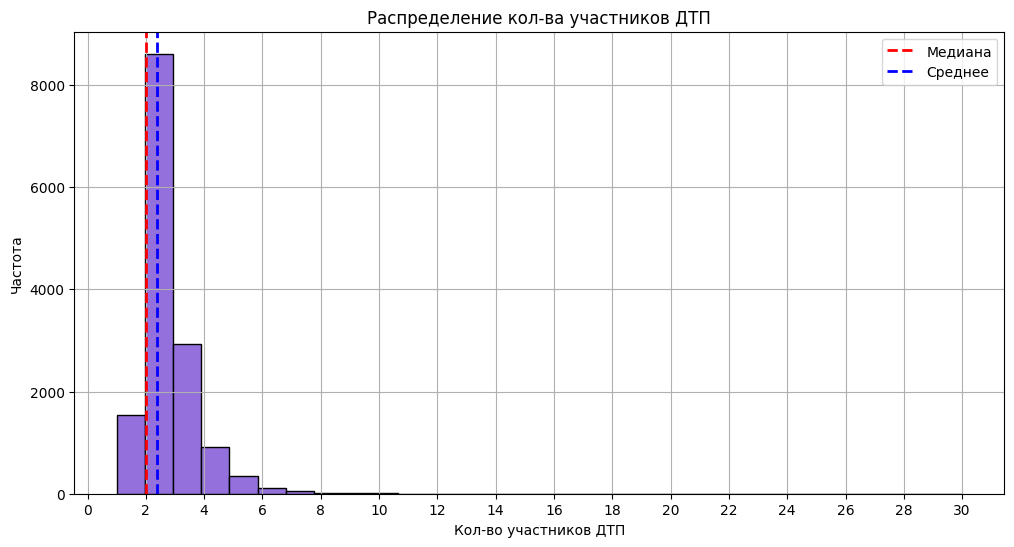

In [27]:
# Построим гистограмму распределения
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    kirov_obl["participants_count"], bins=30, color="mediumpurple", edgecolor="black"
)

plt.axvline(2.0, linestyle="--", linewidth=2, label="Медиана", color="red")
plt.axvline(2.4, linestyle="--", linewidth=2, label="Среднее", color="blue")
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

ax.set_xlabel("Кол-во участников ДТП")
ax.set_ylabel("Частота")
ax.set_title("Распределение кол-ва участников ДТП")
plt.legend()
plt.grid()
plt.show()

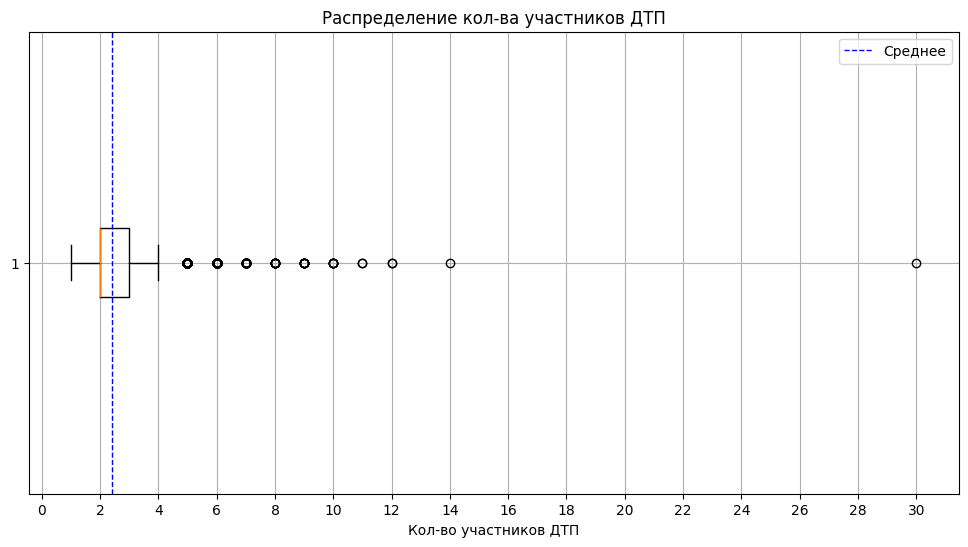

In [28]:
# Построим боксплот для определения выбросов
fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(kirov_obl["participants_count"], vert=False)

plt.axvline(2.4, linestyle="--", linewidth=1, label="Среднее", color="blue")

ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

ax.set_xlabel("Кол-во участников ДТП")
ax.set_title("Распределение кол-ва участников ДТП")
plt.legend()
plt.grid()
plt.show()

In [29]:
print(
    f'Процент ДТП с кол-вом участников от 4 человек: {round(
    kirov_obl[kirov_obl["participants_count"] > 4].shape[0] / kirov_obl.shape[0] * 100,
    2,
)}%'
)

Процент ДТП с кол-вом участников от 4 человек: 3.69%


По гистограмме и боксплоту мы видим, что среднее незначительно отличается от медианы. Это означает, информация о кол-ве участников стабильна и имеет минимальное кол-во аномалий. Выбиваются из основной массы значения от 5 до 30 участников ДТП. Такие значения редкие и составляют всего 3,69% от всех данных. Можно предположить, что значения от 5 до 10 человек в ДТП реальные и редкие. ДТП с 12 до 30 человек скорее всего ошибки при заполнении в данных. 

Чаще всего **в ДТП участвуют 2-4 человека**. За типичное число участников возьмем **медиану - 2 человека**

### 3.4 Поиск корреляции между данными

Вопрос заказчика: предположите, между какими столбцами в датасете `Kirovskaya_oblast.csv` высокая корреляция. Проверьте своё предположение.  

In [30]:
# Построим матрицу корреляций на числовых значениях
kirov_obl.corr(numeric_only=True)

,id,point_lat,point_long,scheme,injured_count,participants_count,datetime_dayweek
id,1.000000,0.044838,0.000309,-0.014990,-0.001796,-0.011355,0.004096
point_lat,0.044838,1.000000,0.004421,0.021044,-0.029886,-0.000820,-0.018779
point_long,0.000309,0.004421,1.000000,0.003064,-0.005333,-0.008409,0.012691
scheme,-0.014990,0.021044,0.003064,1.000000,-0.164936,-0.312146,-0.017958
injured_count,-0.001796,-0.029886,-0.005333,-0.164936,1.000000,0.727196,0.056263
participants_count,-0.011355,-0.000820,-0.008409,-0.312146,0.727196,1.000000,0.042475
datetime_dayweek,0.004096,-0.018779,0.012691,-0.017958,0.056263,0.042475,1.000000


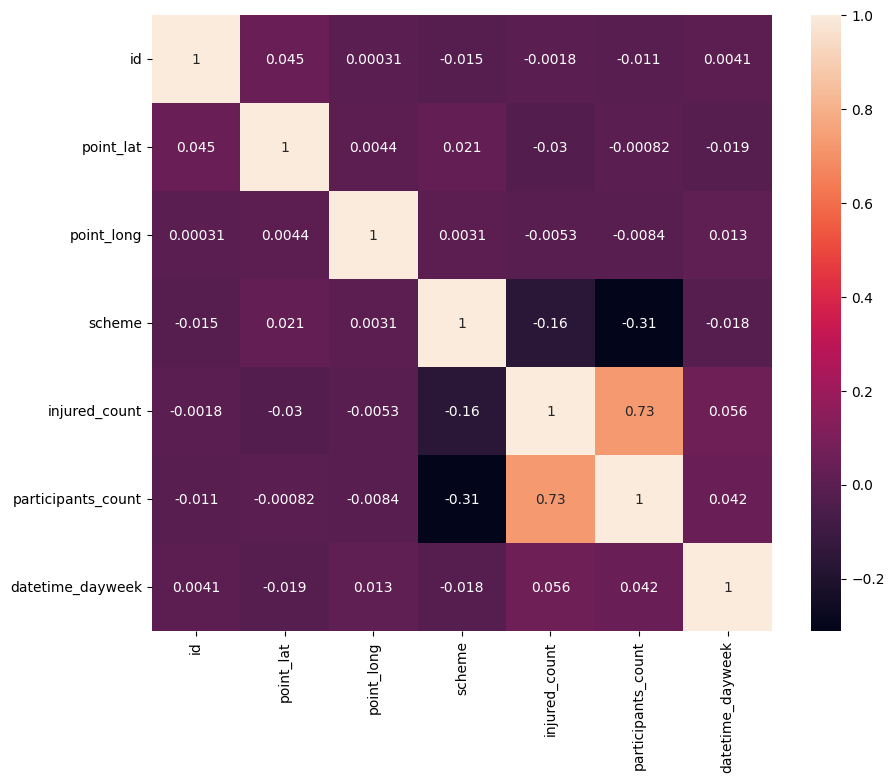

In [31]:
# Построим тепловую карту для наглядности
plt.figure(figsize=(10, 8))
sns.heatmap(
    kirov_obl.corr(numeric_only=True),
    annot=True,
)
plt.show()

Видим сильную положительную корреляцию между числом участников ДТП (`participants_count`) и числом пострадавших (`injured_count`) - **коэф. корреляции 0.73**. Вероятно, что с увеличением числа людей, участвовавших в ДТП, растет и число пострадавших.

Также можем заметить, слабую отрицательную корреляцию между номером схемы ДТП (`scheme`) и людьми, которые участвовали или пострадали в ДТП. Возможно, характеристики схемы как-то связаны с происходящими ДТП и людьми, которых это затронуло. При имеющихся данных, сложно предположить, как именно схема влияет на ДТП.

### 3.5 Связь между категорией аварии и погодными условиями

Вопрос от заказчика: как связаны категории аварий и погодные условия?

In [32]:
# Построим сводную таблицу по категории и погодным условиям
pivot_kirov_obl = kirov_obl.pivot_table(
    index="category", columns="weather", values="id", aggfunc="count", fill_value=0
)

# Cортируем строки и колонки по убыванию числа аварий
row_pivot = pivot_kirov_obl.max(axis=1).sort_values(ascending=False).index
col_pivot = pivot_kirov_obl.max(axis=0).sort_values(ascending=False).index

# Оставим топ-5 видов аварий и погодных условий по числу аварий
pivot_sorted = pivot_kirov_obl.loc[row_pivot[:5], col_pivot[:5]]
pivot_sorted

weather,['Пасмурно'],['Ясно'],['Снегопад'],['Дождь'],"['Пасмурно', 'Снегопад']"
category,,,,,
Столкновение,2514,2288,274,205,47
Наезд на пешехода,2268,1572,200,220,27
Съезд с дороги,431,586,50,51,13
Опрокидывание,367,532,27,40,13
Наезд на велосипедиста,171,397,1,17,0


Сначала разберем две самые большие категории по числу аварий - Столкновение (с другой машиной) и наезд на пешехода. 

Столкновение чаще всего происходит в пасмурную погоду, и при этом кол-во столкновений в ясную погоду незначительно падает. Можно предположить, что пасмурная и ясная погода практически равнозначны при столкновениях двух машин. Например, в пасмурную погоду у водителя хуже видимость и состояние (сонливость и др.), а в ясную погоду может быть больше машин или яркое солнце, которые слепит глаза.

Наезд на пешехода чаще происходит в пасмурную погоду и тут уже есть значительная разница с ясной погодой (2268 vs 1572). Возможно, в ясную погоду проще заметить пешехода и остановиться, так как скорость столкновеления пешехода с машиной меньше, чем машина с машиной.

Если смотреть в целом, разделение на пасмурную и ясную погоду по числу ДТП практически одинаково.

Аварий в снегопад или дождь гораздо меньше, это может объясняется тем, что в обыденную погоду (ясно или пасмурно) водители пренебрегают вниманием на дорогу, а в снегопад или дождь наоборот, максимально концентрируются при вождении.

### 3.6 Распределение аварий по освещенности дороги и по полу водителя

Вопрос от заказчика: Постройте процентную разбивку аварий по видам освещённости. При этом учитывайте пол участника и сделайте расчёты для мужчин и женщин отдельно.

Используем два датасета. С информацией о ДТП (`kirov_obl`) и информацией об участниках ДТП (`kirov_obl_people`)

In [33]:
# Для начала проверим данные на наличие дубликатов у водителей
kirov_obl_people[kirov_obl_people["role"] == "Водитель"]["id"].value_counts()

id
1985567    6
1984910    6
2649405    6
1984276    6
1988052    5
          ..
2553530    1
1982056    1
1984627    1
1982154    1
1987674    1
Name: count, Length: 13025, dtype: int64

Дубликаты в данных есть. Создадим новый датасет, в котором оставим только водителей и удалим дубликаты:

In [34]:
kirov_obl_drivers = kirov_obl_people.query('role == "Водитель"')
kirov_obl_drivers = kirov_obl_drivers.drop_duplicates(subset="id")

Соединим датасеты по id ДТП:

In [35]:
df_merge = kirov_obl_drivers.merge(kirov_obl, on="id", how="inner")

In [36]:
# Рассчитаем кол-во аварий по типу освещенности и полу водителя
df_grouped = (
    df_merge.groupby(["light", "gender"])["id"]
    .nunique()
    .reset_index()
    .sort_values("light")
)

df_grouped

,light,gender,id
0,"В темное время суток, освещение включено",Женский,376
1,"В темное время суток, освещение включено",Мужской,2372
2,"В темное время суток, освещение не включено",Женский,18
3,"В темное время суток, освещение не включено",Мужской,164
4,"В темное время суток, освещение отсутствует",Женский,168
5,"В темное время суток, освещение отсутствует",Мужской,1067
6,Светлое время суток,Женский,1096
7,Светлое время суток,Мужской,6905
8,Сумерки,Женский,48
9,Сумерки,Мужской,339


In [ ]:
# Напишем функцию для подсчета общего кол-ва уникальных водителей в зависимости от пола
def driver_gender(df):
    """
    Функция принимает датафрейм и возвращает уникальное кол-во водителей в зависимости от пола водителя
    """
    if df["gender"] == "Мужской":
        return df_merge[df_merge["gender"] == "Мужской"]["id"].nunique()
    if df["gender"] == "Женский":
        return df_merge[df_merge["gender"] == "Женский"]["id"].nunique()

In [ ]:
# Применяем функцию к сгруппированному датафрейму
df_grouped["drivers"] = df_grouped.apply(driver_gender, axis=1)

In [39]:
# Считаем процент водителей по типу освещения и полу
df_grouped["percent"] = (df_grouped["id"] / df_grouped["drivers"] * 100).round(1)

# Ознакомимся с полученными данными
df_grouped.sort_values(by=["gender", "percent"], ascending=False)[
    ["gender", "light", "id", "drivers", "percent"]
]

,gender,light,id,drivers,percent
7,Мужской,Светлое время суток,6905,10847,63.7
1,Мужской,"В темное время суток, освещение включено",2372,10847,21.9
5,Мужской,"В темное время суток, освещение отсутствует",1067,10847,9.8
9,Мужской,Сумерки,339,10847,3.1
3,Мужской,"В темное время суток, освещение не включено",164,10847,1.5
6,Женский,Светлое время суток,1096,1706,64.2
0,Женский,"В темное время суток, освещение включено",376,1706,22.0
4,Женский,"В темное время суток, освещение отсутствует",168,1706,9.8
8,Женский,Сумерки,48,1706,2.8
2,Женский,"В темное время суток, освещение не включено",18,1706,1.1


Для мужчин и женщин характерны ДТП в светлое время суток (63.7% у мужчин и 64.2% у женщин).

### 3.7 Различия аварий без пострадавших и аварий с одним и более пострадавшими

Вопрос от заказчика: исследуйте, чем отличаются аварии без пострадавших от тех, в которых был один пострадавший или более.

In [ ]:
# Рассмотрим распределение кол-ва аварий по числу пострадавших в соединенном датафрейме
df_merge["injured_count"].value_counts()

injured_count
1     10445
2      1711
3       540
4       212
5        72
6        26
7        10
8         4
9         2
30        1
10        1
12        1
Name: count, dtype: int64

В датасете нет информации о авариях без пострадавших. Можем использовать столбец `health_status` со статусом "Не пострадал" из датасета о участниках ДТП.

Сохраним `id` аварий с пострадавшими, так как в аварии может быть несколько участников и сложнее проверить, что не все из них пострадали.

In [ ]:
id_injured = df_merge.query('health_status != "Не пострадал"')["id"].unique()

In [47]:
df_merge.columns

Index(['role', 'gender', 'violations', 'health_status',
       'years_of_driving_experience', 'id', 'category_exp',
       'category_exp_extra', 'geometry_coordinates', 'tags', 'light',
       'point_lat', 'point_long', 'nearby', 'region', 'scheme', 'address',
       'weather', 'category', 'datetime', 'injured_count', 'parent_region',
       'road_conditions', 'participants_count', 'participant_categories',
       'datetime_dayname', 'datetime_dayweek', 'datetime_month'],
      dtype='object')

Исследуем условия ДТП с пострадавшими и без них. За условия, при которых происходит ДТП, возьмем освещенность, погоду, категорию ДТП, состояние дороги и категорию участников ДТП

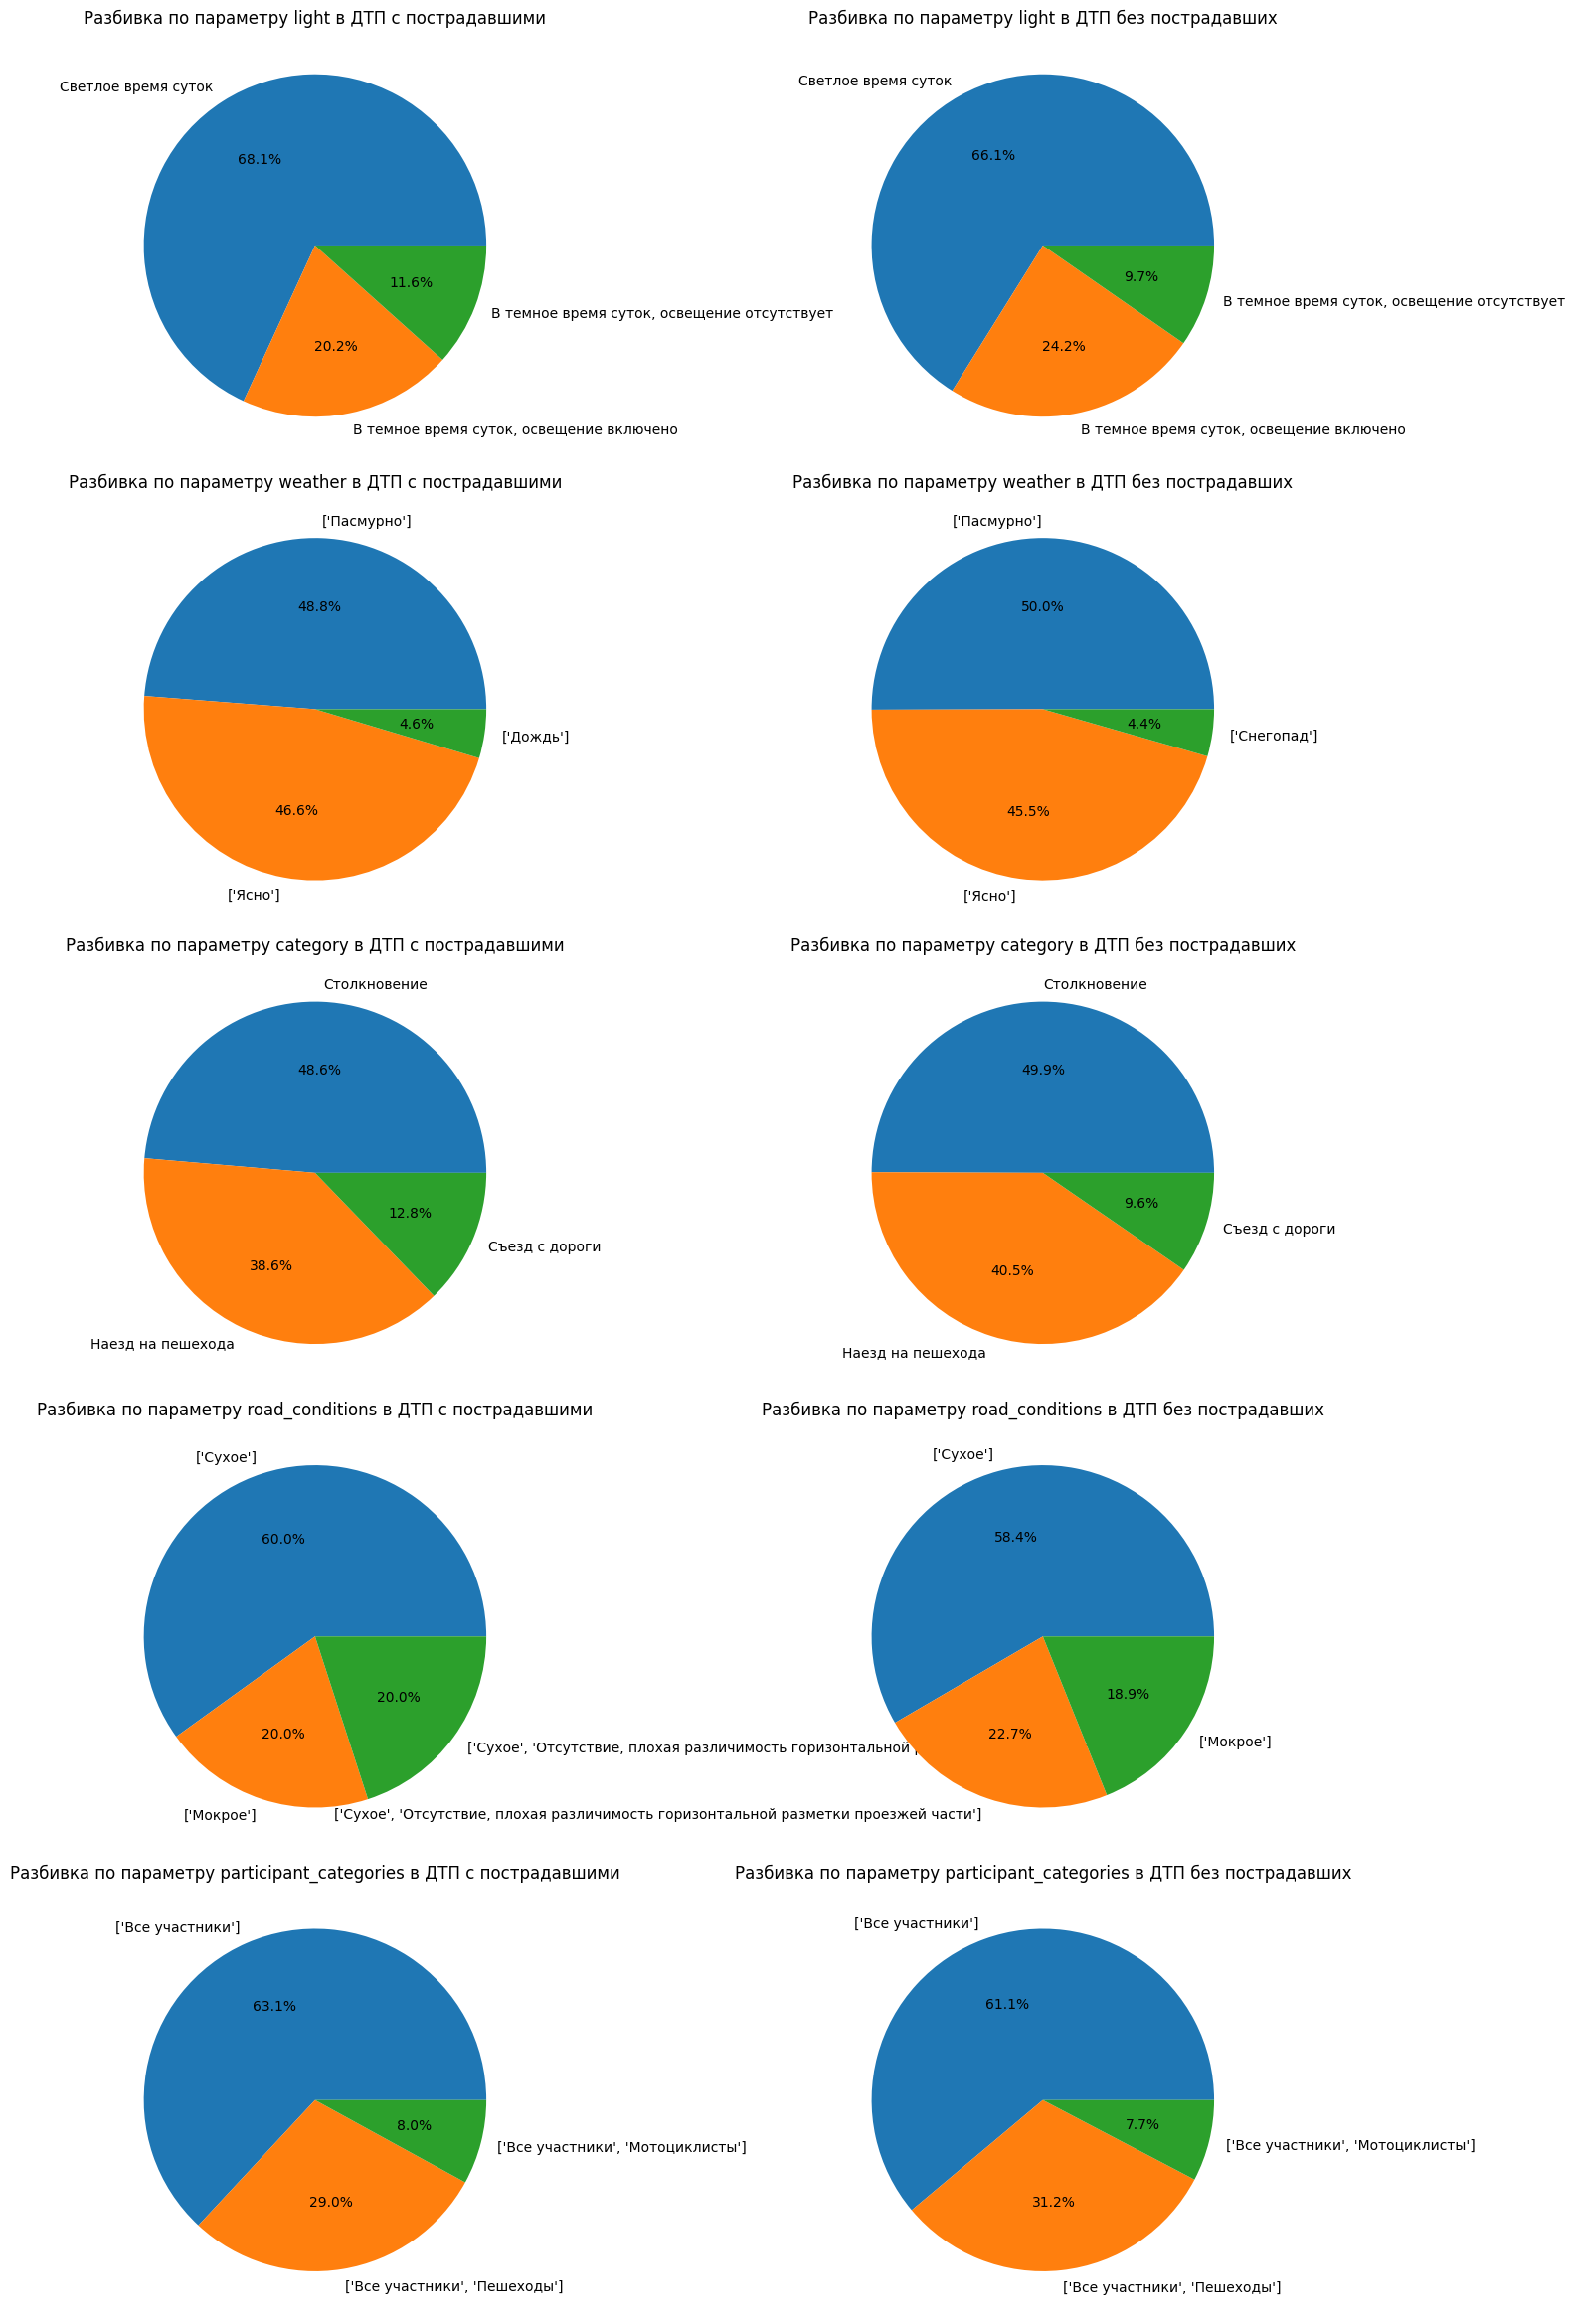

In [70]:
# Настраиваем ось и фигуру
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 30))

# Настраиваем отступы между графиками по горизонтали и вертикали
plt.subplots_adjust(wspace=0.7, hspace=0.05)

# Переменная counter будет указывать на текущую строку (0–4)
counter = 0

# Для каждого из пяти столбцов выполняется одинаковый блок.
for col in [
    "light",
    "weather",
    "category",
    "road_conditions",
    "participant_categories",
]:
    df_injured = (
        df_merge.query("id in @id_injured")[col]
        .value_counts(normalize=True)
        .reset_index()[0:3]
    )
    df_no_injured = (
        df_merge.query("id not in @id_injured")[col]
        .value_counts(normalize=True)
        .reset_index()[0:3]
    )

    # Строим круговую диаграмму на указанной оси axes[counter, 0] (левый столбец)
    df_injured.plot.pie(
        ax=axes[counter, 0],
        y="proportion",
        autopct="%1.1f%%",
        labels=df_injured[col],
        legend=False,
        ylabel="",
    )
    axes[counter, 0].set_title(f"Разбивка по параметру {col} в ДТП c пострадавшими")

    # Строим круговую диаграмму на указанной оси axes[counter, 1] (правый столбец)
    df_no_injured.plot.pie(
        ax=axes[counter, 1],
        y="proportion",
        autopct="%1.1f%%",
        labels=df_no_injured[col],
        legend=False,
        ylabel="",
    )
    axes[counter, 1].set_title(f"Разбивка по параметру {col} в ДТП без пострадавших")

    # Переход к следующей строке для следующего признака
    counter += 1

plt.show()

По основным условиям, при которых происходят аварии, значительных различий между ДТП с пострадавшими и без них не выявлено.

### 3.8 Общие выводы о связи аварий с другими факторами

Выводы:

- **По временным промежуткам** большинство аварий зафиксировано в летнии периоды (Август, Июль, Июнь) и предвыходные и выходные дни (Пятница, Суббота, Воскресенье). Это может быть логично, так как летом в принципе наблюдается больше машин на дорогах. Можно предположить, что в Пятницу, люди можно сказать "головой уже дома", когда едут с работы, теряется концентрация.

- **По стажу вождения** наблюдается большиноство аварий у водителей с малым стажем от 0 до 5 лет. С увеличеним стажа вождения падает кол-во ДТП. **Это лишь предположение**, для более точной оценки, стоит узнать сколько водителей в каждой когорте категории стажа.

- Чаще всего в ДТП участвуют от 2 до 4 человек. Типичное значение - 2 человека. Такое число участников ДТП скорее всего связано с его типом, например самыми "популярными" ДТП являются "Столкновение машин" и "Наезд на пешехода", где зачастую участвуют два человека.

- Больше всего ДТП, с столновением машин и наездом на пешехода, происходят в пасмурную погоду, при этом кол-во ДТП в ясную погоду незначительно меньше. Это может означать, что оба условия практически одинаково влияют на водителей.

    В снегопад и дождь ДТП в десятки раз меньше, первопричиной этого меньшинства является то, что аварий в летние периоды при пасмурной и ясной погоде зафиксировано больше всего и это может являтся просто модой (cамым частым значением) всего датасета. Стоит рассмотреть исследование на более большом промежутке данных. Второстепенной причиной может являться то, что таких погодных условиях, водители ведут себя более внимательно.

- Существенного различия между типами освещенности и полом водителя не выявлено.

- По признакам ДТП (освещенность, состояние дороги и др.) различий между ДТП с пострадвшими и без них не выявлено. 

Рекомендации по улучшению качества данных:

- Сделать столбцы с координатами `point_long`, `point_lat` обязательными для заполнения. Это поможет вычислить локацию, ближайший адрес, ближайшие объекты, которые были при совершении ДТП, и в принципе лучше анализировать и описывать аварии.

- Стоит оптимизировать форматы поступающих данных, это поможет увеличить скорость обработки данных системой и сэконимить место

- Сделать столбец со стажем обязательным для заполнения. В нём 2844 пропусков — 14% от общего числа. Тех, у кого не было прав, можно фиксировать отдельно. Вероятно, что причина отсутствия прав также важна: их забрали или водитель их не получил.